In [1]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects, fitGaussian2D
import os
import matplotlib.pyplot as plt
import referenceFrames as rf
import numpy as np
import math
import tables
import scipy.constants as constants

In [2]:
sim = Simulation("PSF")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# One full-frame exposure

sim["ObservingParameters/NumExposures"] = 1

sim["CCD/IncludeConvolution"] = "yes"

starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"
sim.createStarCatalogFileFromPixelCoordinates(np.array([100]), np.array([100]), np.array([12.5]), np.array([1]), starCatalogFilename)
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

dim = 20
sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim
sim["SubField/ZeroPointRow"] = 100 - dim // 2
sim["SubField/ZeroPointColumn"] = 100 - dim // 2

sim["ControlHDF5Content/WriteSubPixelImages"] = "yes"
numSubPixels = sim["SubField/SubPixels"]
print(numSubPixels)

8


# Gaussian PSF

In [3]:
sim["PSF/Model"] = "MappedGaussian"
sigma = sim["PSF/MappedGaussian/Sigma"]

output = sim.run(removeOutputFile = True)
image = output.getImage(0)
subPixelImage = output.getSubPixelImage(0)

In [4]:
offsets = np.arange(0.0, 1, 0.1 / numSubPixels)

fittedSigmaPixel = np.array([])
fittedRowsPixel = np.array([])
fittedColumnsPixel = np.array([])
fittedSigmaSubPixel = np.array([])
fittedRowsSubPixel = np.array([])
fittedColumnsSubPixel = np.array([])
    
for offset in offsets:

    sim.createStarCatalogFileFromPixelCoordinates(np.array([100 + offset]), np.array([100 + offset]), np.array([12.5]), np.array([1]), starCatalogFilename)
    sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename
    
    sim["PSF/Model"] = "MappedGaussian"
    sigma = sim["PSF/MappedGaussian/Sigma"]

    output = sim.run(removeOutputFile = True)
    image = output.getImage(0)
    subPixelImage = output.getSubPixelImage(0)
    
    print("Offset:", offset)
    print("******* \n")
    
    params = fitGaussian2D(image, np.max(image), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
    print("Pixel level:")
    print("------------")
    print("Position:", params[1], params[2])
    print("Sigma:", params[3], "\n")
    fittedSigmaPixel = np.append(fittedSigmaPixel, params[3])
    fittedRowsPixel = np.append(fittedRowsPixel, params[1])
    fittedColumnsPixel = np.append(fittedColumnsPixel, params[2])

    params = fitGaussian2D(subPixelImage, np.max(subPixelImage), dim * numSubPixels / 2, dim * numSubPixels / 2, sigma * numSubPixels, sigma * numSubPixels, subtractConstant = True)
    print("Sub-pixel level:")
    print("----------------")
    print("Position:", params[1] / numSubPixels, params[2] / numSubPixels)
    print("Sigma:", params[3] / numSubPixels)
    fittedSigmaSubPixel = np.append(fittedSigmaSubPixel, params[3] / numSubPixels)
    fittedRowsSubPixel = np.append(fittedRowsSubPixel, params[1] / numSubPixels)
    fittedColumnsSubPixel = np.append(fittedColumnsSubPixel, params[2] / numSubPixels)



Offset: 0.0
******* 

Pixel level:
------------
Position: 9.438208412264942 9.438208418082656
Sigma: 0.7011502539879009 

Sub-pixel level:
----------------
Position: 9.874999998805453 9.87500000538104
Sigma: 0.6390004212100912


Offset: 0.0125
******* 

Pixel level:
------------
Position: 9.561791586231026 9.561791585352433
Sigma: 0.7011502169977406 

Sub-pixel level:
----------------
Position: 10.000000003097252 9.999999999319336
Sigma: 0.6390004179659307


Offset: 0.025
******* 

Pixel level:
------------
Position: 9.561791586231026 9.561791585352433
Sigma: 0.7011502169977406 

Sub-pixel level:
----------------
Position: 10.000000003097252 9.999999999319336
Sigma: 0.639000417965931


Offset: 0.037500000000000006
******* 

Pixel level:
------------
Position: 9.561791586231026 9.561791585352433
Sigma: 0.7011502169977406 

Sub-pixel level:
----------------
Position: 10.000000003097252 9.999999999319336
Sigma: 0.6390004179659307


Offset: 0.05
******* 

Pixel level:
------------
Positi

Sub-pixel level:
----------------
Position: 10.375000003989612 10.375000014019864
Sigma: 0.6390004156270918


Offset: 0.4375
******* 

Pixel level:
------------
Position: 9.9370172999098 9.93701726956779
Sigma: 0.7045927258271353 

Sub-pixel level:
----------------
Position: 10.37500000398962 10.375000014019852
Sigma: 0.6390004156270885


Offset: 0.45
******* 

Pixel level:
------------
Position: 9.9370172999098 9.93701726956779
Sigma: 0.7045927258271353 

Sub-pixel level:
----------------
Position: 10.375000003989607 10.375000014019859
Sigma: 0.6390004156270775


Offset: 0.4625
******* 

Pixel level:
------------
Position: 9.9370172999098 9.93701726956779
Sigma: 0.7045927258271353 

Sub-pixel level:
----------------
Position: 10.375000003989612 10.375000014019864
Sigma: 0.6390004156270918


Offset: 0.47500000000000003
******* 

Pixel level:
------------
Position: 9.9370172999098 9.93701726956779
Sigma: 0.7045927258271353 

Sub-pixel level:
----------------
Position: 10.37500000398962 



Offset: 0.8625
******* 

Pixel level:
------------
Position: 10.313971930778472 10.313972006164008
Sigma: 0.7025906051713455 

Sub-pixel level:
----------------
Position: 10.7499999893342 10.749999990339436
Sigma: 0.639000419175968


Offset: 0.875
******* 

Pixel level:
------------
Position: 10.31397187440291 10.438208435051509
Sigma: 0.7025908986589704 

Sub-pixel level:
----------------
Position: 10.749999990563122 10.87499999678974
Sigma: 0.639000421647258


Offset: 0.8875000000000001
******* 

Pixel level:
------------
Position: 10.438208363476695 10.438208374343048
Sigma: 0.7011502740521731 

Sub-pixel level:
----------------
Position: 10.87499997753498 10.874999988914016
Sigma: 0.6390004285376221


Offset: 0.9
******* 

Pixel level:
------------
Position: 10.438208363476695 10.438208374343048
Sigma: 0.7011502740521731 

Sub-pixel level:
----------------
Position: 10.87499997753498 10.874999988914018
Sigma: 0.6390004285376226


Offset: 0.9125000000000001
******* 

Pixel level:


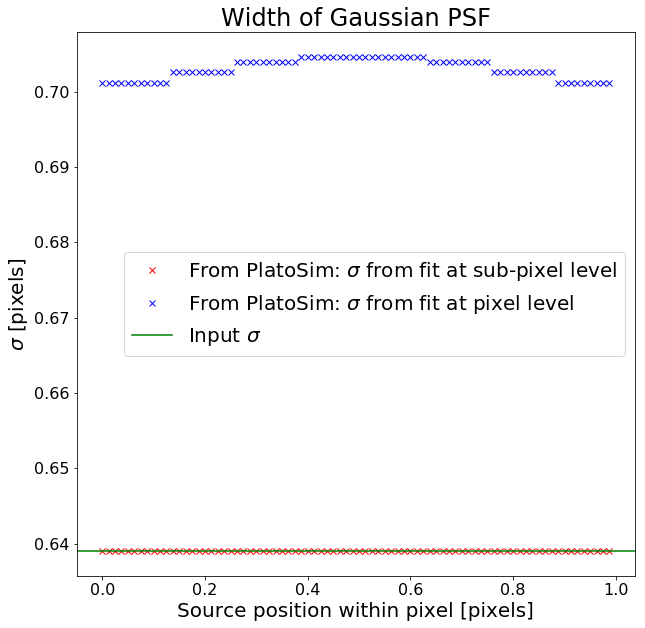

In [5]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(offsets, fittedSigmaSubPixel, "rx", label = "From PlatoSim: $\\sigma$ from fit at sub-pixel level")
plt.plot(offsets, fittedSigmaPixel, "bx", label = "From PlatoSim: $\\sigma$ from fit at pixel level")

plt.axhline(y = sigma, color = "g", label = "Input $\\sigma$")


########
# Layout
########

plt.title("Width of Gaussian PSF", fontsize = 24)
plt.xlabel("Source position within pixel [pixels]", fontsize = 20)
plt.ylabel("$\\sigma$ [pixels]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

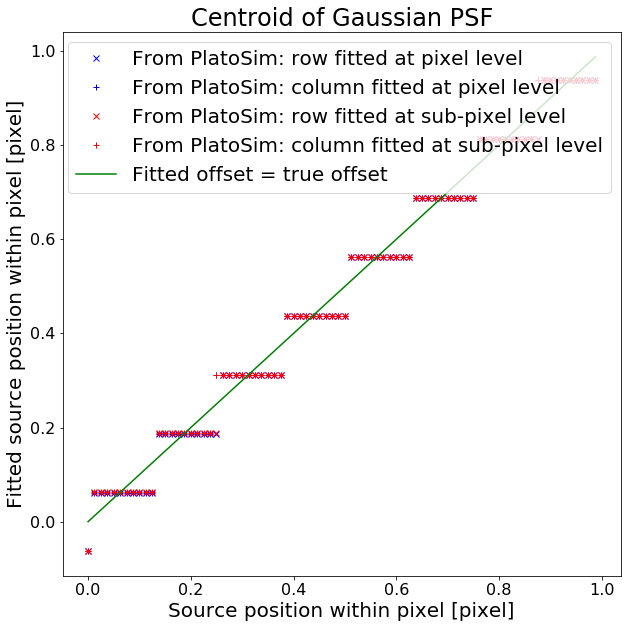

In [6]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(offsets, fittedRowsPixel + 0.5 - (dim / 2), "bx", label = "From PlatoSim: row fitted at pixel level")
plt.plot(offsets, fittedColumnsPixel + 0.5 - (dim / 2), "b+", label = "From PlatoSim: column fitted at pixel level")

plt.plot(offsets, fittedRowsSubPixel + 0.5 / numSubPixels - (dim / 2), "rx", label = "From PlatoSim: row fitted at sub-pixel level")
plt.plot(offsets, fittedColumnsSubPixel + 0.5 / numSubPixels - (dim / 2), "r+", label = "From PlatoSim: column fitted at sub-pixel level")

plt.plot(offsets, (dim / 2) + offsets - (dim / 2), "g", label = "Fitted offset = true offset")

########
# Layout
########

plt.title("Centroid of Gaussian PSF", fontsize = 24)
plt.xlabel("Source position within pixel [pixel]", fontsize = 20)
plt.ylabel("Fitted source position within pixel [pixel]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

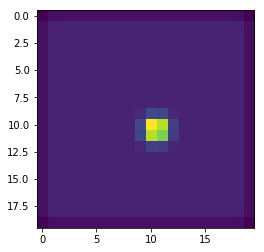

In [7]:
plt.imshow(image)

In [8]:
ID, rows, columns, Xmm, Ymm, flux = output.getStarCoordinates(0)

# Pre-Computed PSF

In [9]:
offsets = np.arange(0.0, 1, 0.1 / numSubPixels)
# offsets = np.arange(0.0, 0.5, 0.1/numSubPixels)

fittedSigmaPixel = np.array([])
fittedRowsPixel = np.array([])
fittedColumnsPixel = np.array([])
fittedSigmaSubPixel = np.array([])
fittedRowsSubPixel = np.array([])
fittedColumnsSubPixel = np.array([])
    
for offset in offsets:

    sim.createStarCatalogFileFromPixelCoordinates(np.array([100 + offset]), np.array([100 + offset]), np.array([12.5]), np.array([1]), starCatalogFilename)
    sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename
    
    sim["PSF/Model"] = "MappedFromFile"

    output = sim.run(removeOutputFile = True)
    image = output.getImage(0)
    subPixelImage = output.getSubPixelImage(0)
    
    print("Offset:", offset)
    print("******* \n")
    
    params = fitGaussian2D(image, np.max(image), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
    print("Pixel level:")
    print("------------")
    print("Position:", params[1], params[2])
    print("Sigma:", params[3], "\n")
    fittedSigmaPixel = np.append(fittedSigmaPixel, params[3])
    fittedRowsPixel = np.append(fittedRowsPixel, params[1])
    fittedColumnsPixel = np.append(fittedColumnsPixel, params[2])

    params = fitGaussian2D(subPixelImage, np.max(subPixelImage), dim * numSubPixels / 2, dim * numSubPixels / 2, sigma * numSubPixels, sigma * numSubPixels, subtractConstant = True)
    print("Sub-pixel level:")
    print("----------------")
    print("Position:", params[1] / numSubPixels, params[2] / numSubPixels)
    print("Sigma:", params[3] / numSubPixels)
    fittedSigmaSubPixel = np.append(fittedSigmaSubPixel, params[3] / numSubPixels)
    fittedRowsSubPixel = np.append(fittedRowsSubPixel, params[1] / numSubPixels)
    fittedColumnsSubPixel = np.append(fittedColumnsSubPixel, params[2] / numSubPixels)



Offset: 0.0
******* 

Pixel level:
------------
Position: 9.287778639852032 9.287778670021108
Sigma: 0.4706751267620457 

Sub-pixel level:
----------------
Position: 9.820736573854186 9.82073657836152
Sigma: 0.11136080410813959


Offset: 0.0125
******* 

Pixel level:
------------
Position: 9.515125394008091 9.515125417108345
Sigma: 0.533255481493235 

Sub-pixel level:
----------------
Position: 9.945736482218653 9.945736482150068
Sigma: 0.11136174276074956


Offset: 0.025
******* 

Pixel level:
------------
Position: 9.515125394008091 9.515125417108345
Sigma: 0.533255481493235 

Sub-pixel level:
----------------
Position: 9.945736482220878 9.945736482154897
Sigma: 0.1113617428798036


Offset: 0.037500000000000006
******* 

Pixel level:
------------
Position: 9.515125394008091 9.515125417108345
Sigma: 0.533255481493235 

Sub-pixel level:
----------------
Position: 9.945736482214933 9.945736482148043
Sigma: 0.11136174283258332


Offset: 0.05
******* 

Pixel level:
------------
Position



Offset: 0.4375
******* 

Pixel level:
------------
Position: 9.907148936028054 9.907148948399723
Sigma: 0.45066364164608036 

Sub-pixel level:
----------------
Position: 10.320736575235191 10.320736574794688
Sigma: 0.11136081729240592


Offset: 0.45
******* 

Pixel level:
------------
Position: 9.907148936028054 9.907148948399723
Sigma: 0.45066364164608036 

Sub-pixel level:
----------------
Position: 10.320736575232194 10.320736574796104
Sigma: 0.11136081727137201


Offset: 0.4625
******* 

Pixel level:
------------
Position: 9.907148936028054 9.907148948399723
Sigma: 0.45066364164608036 

Sub-pixel level:
----------------
Position: 10.320736575235548 10.320736574800147
Sigma: 0.11136081721392023


Offset: 0.47500000000000003
******* 

Pixel level:
------------
Position: 9.907148936028054 9.907148948399723
Sigma: 0.45066364164608036 

Sub-pixel level:
----------------
Position: 10.320736575235191 10.320736574794688
Sigma: 0.11136081729240592


Offset: 0.48750000000000004
******* 

P



Offset: 0.8625
******* 

Pixel level:
------------
Position: 10.19232002903769 10.192320052180158
Sigma: 0.45811519642780557 

Sub-pixel level:
----------------
Position: 10.69573666709424 10.695736666892733
Sigma: 0.11135990753933202


Offset: 0.875
******* 

Pixel level:
------------
Position: 10.190337308026248 10.290230748909385
Sigma: 0.46113017157452973 

Sub-pixel level:
----------------
Position: 8.915830327643539 8.751045928158469
Sigma: 0.32453746134501826


Offset: 0.8875000000000001
******* 

Pixel level:
------------
Position: 10.287778612911534 10.287778600705124
Sigma: 0.4706749688905718 

Sub-pixel level:
----------------
Position: 8.87925844836864 8.879259072824814
Sigma: 0.09052072183526788


Offset: 0.9
******* 

Pixel level:
------------
Position: 10.287778612911534 10.287778600705124
Sigma: 0.4706749688905718 

Sub-pixel level:
----------------
Position: 8.879258462774896 8.879259084008227
Sigma: 0.0905206567491696


Offset: 0.9125000000000001
******* 

Pixel lev

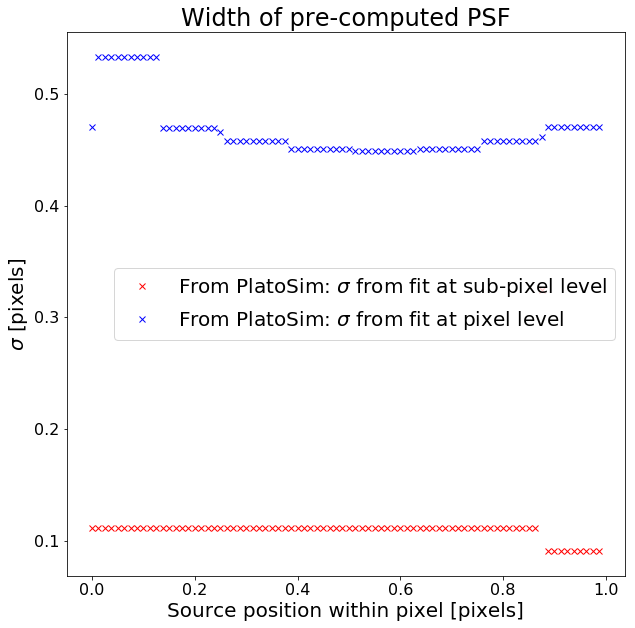

In [10]:
# fig = plt.figure(figsize = (10, 10))
# ax = fig.add_subplot(1, 1, 1)



# plt.plot(offsets, fittedSigmaSubPixel, "rx", label = "From PlatoSim: $\\sigma$ from fit at sub-pixel level")
# plt.plot(offsets, fittedSigmaPixel, "bx", label = "From PlatoSim: $\\sigma$ from fit at pixel level")


# ########
# # Layout
# ########

# plt.title("Width of pre-computed PSF", fontsize = 24)
# plt.xlabel("Source position within pixel [pixels]", fontsize = 20)
# plt.ylabel("$\\sigma$ [pixels]", fontsize = 20)

# plt.legend(loc='best', fontsize = 20)

# for tick in ax.xaxis.get_major_ticks():
#     tick.label.set_fontsize(16)
    
# for tick in ax.yaxis.get_major_ticks():
#     tick.label.set_fontsize(16)


    
    
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(offsets, fittedSigmaSubPixel, "rx", label = "From PlatoSim: $\\sigma$ from fit at sub-pixel level")
plt.plot(offsets, fittedSigmaPixel, "bx", label = "From PlatoSim: $\\sigma$ from fit at pixel level")

# plt.axhline(y = sigma, color = "k", label = "Input $\\sigma$")


########
# Layout
########

plt.title("Width of pre-computed PSF", fontsize = 24)
plt.xlabel("Source position within pixel [pixels]", fontsize = 20)
plt.ylabel("$\\sigma$ [pixels]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

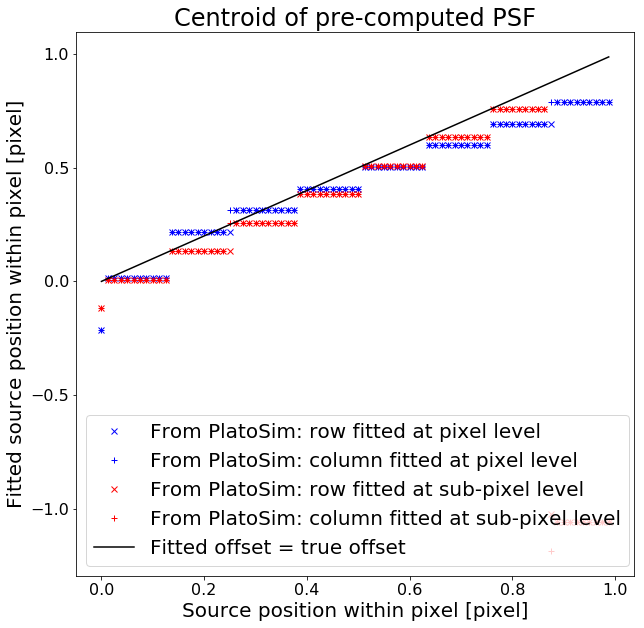

In [11]:
# fig = plt.figure(figsize = (10, 10))
# ax = fig.add_subplot(1, 1, 1)



# plt.plot(offsets, fittedRowsPixel + 0.5 - (dim / 2), "bx", label = "From PlatoSim: row fitted at pixel level")
# plt.plot(offsets, fittedColumnsPixel + 0.5 - (dim / 2), "b+", label = "From PlatoSim: column fitted at pixel level")

# plt.plot(offsets, fittedRowsSubPixel + 0.5 / numSubPixels - (dim / 2), "rx", label = "From PlatoSim: row fitted at sub-pixel level")
# plt.plot(offsets, fittedColumnsSubPixel + 0.5 / numSubPixels - (dim / 2), "r+", label = "From PlatoSim: column fitted at sub-pixel level")

# plt.plot(offsets, (dim / 2) + offsets - (dim / 2), "k", label = "Fitted offset = true offset")



# ########
# # Layout
# ########

# plt.title("Centroid of pre-computed PSF", fontsize = 24)
# plt.xlabel("Source position within pixel [pixel]", fontsize = 20)
# plt.ylabel("Fitted source position within pixel [pixel]", fontsize = 20)

# plt.legend(loc='best', fontsize = 20)

# for tick in ax.xaxis.get_major_ticks():
#     tick.label.set_fontsize(16)
    
# for tick in ax.yaxis.get_major_ticks():
#     tick.label.set_fontsize(16)

fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(offsets, fittedRowsPixel + 0.5 - (dim / 2), "bx", label = "From PlatoSim: row fitted at pixel level")
plt.plot(offsets, fittedColumnsPixel + 0.5 - (dim / 2), "b+", label = "From PlatoSim: column fitted at pixel level")

plt.plot(offsets, fittedRowsSubPixel + 0.5 / numSubPixels - (dim / 2), "rx", label = "From PlatoSim: row fitted at sub-pixel level")
plt.plot(offsets, fittedColumnsSubPixel + 0.5 / numSubPixels - (dim / 2), "r+", label = "From PlatoSim: column fitted at sub-pixel level")

plt.plot(offsets, (dim / 2) + offsets - (dim / 2), "k", label = "Fitted offset = true offset")

########
# Layout
########

plt.title("Centroid of pre-computed PSF", fontsize = 24)
plt.xlabel("Source position within pixel [pixel]", fontsize = 20)
plt.ylabel("Fitted source position within pixel [pixel]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

# Analytic PSF

In [12]:
offsets = np.arange(0.0, 1, 0.1 / numSubPixels)

fittedSigmaPixel = np.array([])
fittedRowsPixel = np.array([])
fittedColumnsPixel = np.array([])
# fittedSigmaSubPixel = np.array([])
# fittedRowsSubPixel = np.array([])
# fittedColumnsSubPixel = np.array([])
    
for offset in offsets:

    sim.createStarCatalogFileFromPixelCoordinates(np.array([100 + offset]), np.array([100 + offset]), np.array([12.5]), np.array([1]), starCatalogFilename)
    sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename
    
    sim["PSF/Model"] = "AnalyticNonGaussian"

    output = sim.run(removeOutputFile = True)
    image = output.getImage(0)
    
    print("Offset:", offset)
    print("******* \n")
    
    params = fitGaussian2D(image, np.max(image), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
    print("Pixel level:")
    print("------------")
    print("Position:", params[1], params[2])
    print("Sigma:", params[3], "\n")
    fittedSigmaPixel = np.append(fittedSigmaPixel, params[3])
    fittedRowsPixel = np.append(fittedRowsPixel, params[1])
    fittedColumnsPixel = np.append(fittedColumnsPixel, params[2])



Offset: 0.0
******* 

Pixel level:
------------
Position: 9.472546304781558 9.4725463047901
Sigma: 0.5353787795532102 



Offset: 0.0125
******* 

Pixel level:
------------
Position: 9.519448517192403 9.519448517194954
Sigma: 0.537151316335389 



Offset: 0.025
******* 

Pixel level:
------------
Position: 9.563265854763653 9.563265855092043
Sigma: 0.5281499546033022 



Offset: 0.037500000000000006
******* 

Pixel level:
------------
Position: 9.598186089959025 9.598186089959025
Sigma: 0.5155300075024835 



Offset: 0.05
******* 

Pixel level:
------------
Position: 9.623468066569762 9.62346806717829
Sigma: 0.5052490119232751 



Offset: 0.0625
******* 

Pixel level:
------------
Position: 9.641541064586606 9.641541066341068
Sigma: 0.4983568140354899 



Offset: 0.07500000000000001
******* 

Pixel level:
------------
Position: 9.655976346158205 9.655976347369036
Sigma: 0.4934655793768277 



Offset: 0.08750000000000001
******* 

Pixel level:
------------
Position: 9.669859417078065 



Offset: 0.7875000000000001
******* 

Pixel level:
------------
Position: 10.21271323457496 10.21271323457496
Sigma: 0.4648488012806013 



Offset: 0.8
******* 

Pixel level:
------------
Position: 10.22193325543566 10.221933255651402
Sigma: 0.4656514378778952 



Offset: 0.8125
******* 

Pixel level:
------------
Position: 10.231536013326556 10.23153601280318
Sigma: 0.4667114028275303 



Offset: 0.8250000000000001
******* 

Pixel level:
------------
Position: 10.241362679067873 10.241362678643958
Sigma: 0.4679461174041769 



Offset: 0.8375
******* 

Pixel level:
------------
Position: 10.250928763026067 10.2509287619857
Sigma: 0.4691029337928747 



Offset: 0.8500000000000001
******* 

Pixel level:
------------
Position: 10.259970386906934 10.259970387579498
Sigma: 0.47004737385869133 



Offset: 0.8625
******* 

Pixel level:
------------
Position: 10.269005116462505 10.269005116462505
Sigma: 0.4710575073831944 



Offset: 0.875
******* 

Pixel level:
------------
Position: 10.2791

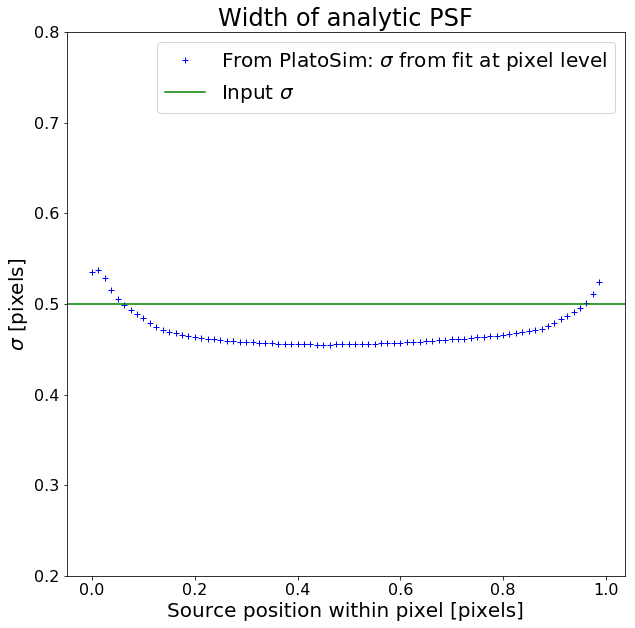

In [13]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)


sigma = sim["PSF/AnalyticNonGaussian/Sigma/ConstantValue"]
plt.plot(offsets, fittedSigmaPixel, "b+", label = "From PlatoSim: $\\sigma$ from fit at pixel level")

plt.axhline(y = sigma, color = "g", label = "Input $\\sigma$")


########
# Layout
########

plt.title("Width of analytic PSF", fontsize = 24)
plt.xlabel("Source position within pixel [pixels]", fontsize = 20)
plt.ylabel("$\\sigma$ [pixels]", fontsize = 20)
plt.ylim([0.2, 0.8])

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

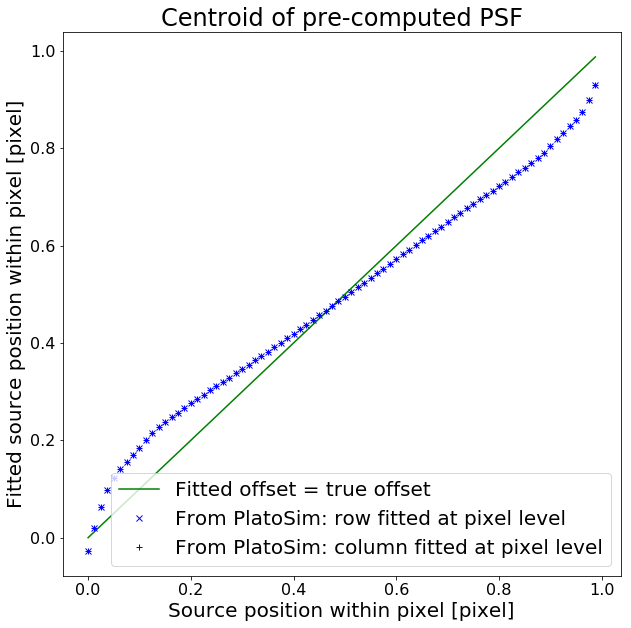

In [14]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



# plt.plot(offsets, fittedRowsPixel + 0.5 - (dim / 2), "bx", label = "From PlatoSim: row fitted at pixel level")
# plt.plot(offsets, fittedColumnsPixel + 0.5 - (dim / 2), "r+", label = "From PlatoSim: column fitted at pixel level")
plt.plot(offsets, (dim / 2) + offsets - (dim / 2), "g", label = "Fitted offset = true offset")

plt.plot(offsets, fittedRowsPixel + 0.5 - (dim / 2), "bx", label = "From PlatoSim: row fitted at pixel level")
plt.plot(offsets, fittedColumnsPixel + 0.5 - (dim / 2), "b+", label = "From PlatoSim: column fitted at pixel level")



########
# Layout
########

plt.title("Centroid of pre-computed PSF", fontsize = 24)
plt.xlabel("Source position within pixel [pixel]", fontsize = 20)
plt.ylabel("Fitted source position within pixel [pixel]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

In [25]:
offsets = np.arange(500, 4700, 100)
sigma = 0.64

fittedSigmaPixel = np.array([])
fittedSigmaSubPixel = np.array([])

for offset in offsets:
    
    sim["SubField/ZeroPointRow"] = offset - dim // 2
    sim["SubField/ZeroPointColumn"] = offset - dim // 2
    
    
    sim.createStarCatalogFileFromPixelCoordinates(np.array([offset]), np.array([offset]), np.array([12.5]), np.array([1]), starCatalogFilename)
    sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename
    
    sim["PSF/Model"] = "MappedFromFile"

    output = sim.run(removeOutputFile = True)
    image = output.getImage(0)
    subPixelImage = output.getSubPixelImage(0)
    
    print("Offset:", offset)
    print("******* \n")
    
    params = fitGaussian2D(image, np.max(image), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
    print("Pixel level:")
    print("------------")
    print("Position:", params[1], params[2])
    print("Sigma:", params[3], "\n")
    fittedSigmaPixel = np.append(fittedSigmaPixel, params[3])

    params = fitGaussian2D(subPixelImage, np.max(subPixelImage), dim * numSubPixels / 2, dim * numSubPixels / 2, sigma * numSubPixels, sigma * numSubPixels, subtractConstant = True)
    print("Sub-pixel level:")
    print("----------------")
    print("Position:", params[1] / numSubPixels, params[2] / numSubPixels)
    print("Sigma:", params[3] / numSubPixels)
    fittedSigmaSubPixel = np.append(fittedSigmaSubPixel, params[3] / numSubPixels)


2019-11-05 10:20:42 WARNING Simulation: no information about detected stars to write to HDF5
2019-11-05 10:20:43 WARNING Camera: No star positions to write to HDF5 file.

Offset: 500
******* 

Pixel level:
------------
Position: 512.0 512.0
Sigma: 0.64 

Sub-pixel level:
----------------
Position: 512.0 512.0
Sigma: 0.64

2019-11-05 10:20:43 WARNING Simulation: no information about detected stars to write to HDF5
2019-11-05 10:20:43 WARNING Camera: No star positions to write to HDF5 file.

Offset: 600
******* 

Pixel level:
------------
Position: 512.0 512.0
Sigma: 0.64 

Sub-pixel level:
----------------
Position: 512.0 512.0
Sigma: 0.64

2019-11-05 10:20:43 WARNING Simulation: no information about detected stars to write to HDF5
2019-11-05 10:20:43 WARNING Camera: No star positions to write to HDF5 file.

Offset: 700
******* 

Pixel level:
------------
Position: 512.0 512.0
Sigma: 0.64 

Sub-pixel level:
----------------
Position: 512.0 512.0
Sigma: 0.64

2019-11-05 10:20:43 WARNING


2019-11-05 10:20:50 WARNING Simulation: no information about detected stars to write to HDF5
2019-11-05 10:20:50 WARNING Camera: No star positions to write to HDF5 file.

Offset: 3100
******* 

Pixel level:
------------
Position: 512.0 512.0
Sigma: 0.64 

Sub-pixel level:
----------------
Position: 512.0 512.0
Sigma: 0.64

2019-11-05 10:20:50 WARNING Simulation: no information about detected stars to write to HDF5
2019-11-05 10:20:50 WARNING Camera: No star positions to write to HDF5 file.

Offset: 3200
******* 

Pixel level:
------------
Position: 512.0 512.0
Sigma: 0.64 

Sub-pixel level:
----------------
Position: 512.0 512.0
Sigma: 0.64

2019-11-05 10:20:51 WARNING Simulation: no information about detected stars to write to HDF5
2019-11-05 10:20:51 WARNING Camera: No star positions to write to HDF5 file.

Offset: 3300
******* 

Pixel level:
------------
Position: 512.0 512.0
Sigma: 0.64 

Sub-pixel level:
----------------
Position: 512.0 512.0
Sigma: 0.64

2019-11-05 10:20:51 WARN

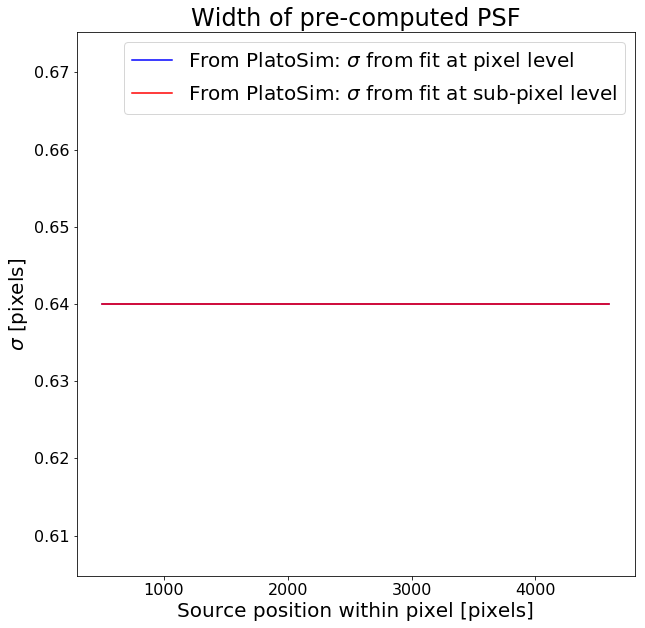

In [26]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)


sigma = sim["PSF/AnalyticNonGaussian/Sigma/ConstantValue"]
plt.plot(offsets, fittedSigmaPixel, "b", label = "From PlatoSim: $\\sigma$ from fit at pixel level")
plt.plot(offsets, fittedSigmaSubPixel, "r", label = "From PlatoSim: $\\sigma$ from fit at sub-pixel level")

# plt.axhline(y = sigma, color = "g", label = "Input $\\sigma$")


########
# Layout
########

plt.title("Width of pre-computed PSF", fontsize = 24)
plt.xlabel("Source position within pixel [pixels]", fontsize = 20)
plt.ylabel("$\\sigma$ [pixels]", fontsize = 20)
# plt.ylim([0.2, 0.8])

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

In [17]:
offsets = np.arange(500, 4700, 100)
dim = 128
fittedSigmaPixel = np.array([])
fittedSigmaSubPixel = np.array([])

for offset in offsets:
    
    sim["SubField/ZeroPointRow"] = offset - dim // 2
    sim["SubField/ZeroPointColumn"] = offset - dim // 2
    
    
    sim.createStarCatalogFileFromPixelCoordinates(np.array([offset]), np.array([offset]), np.array([12.5]), np.array([1]), starCatalogFilename)
    sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename
    
    sim["PSF/Model"] = "AnalyticNonGaussian"

    output = sim.run(removeOutputFile = True)
    image = output.getImage(0)
    
    print("Offset:", offset)
    print("******* \n")
    
    params = fitGaussian2D(image, np.max(image), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
    print("Pixel level:")
    print("------------")
    print("Position:", params[1], params[2])
    print("Sigma:", params[3], "\n")
    fittedSigmaPixel = np.append(fittedSigmaPixel, params[3])


2019-11-05 10:17:38 WARNING Simulation: no information about detected stars to write to HDF5
2019-11-05 10:17:38 WARNING Camera: No star positions to write to HDF5 file.

Offset: 500
******* 

Pixel level:
------------
Position: 64.0 64.0
Sigma: 0.5 


2019-11-05 10:17:38 WARNING Simulation: no information about detected stars to write to HDF5
2019-11-05 10:17:38 WARNING Camera: No star positions to write to HDF5 file.

Offset: 600
******* 

Pixel level:
------------
Position: 64.0 64.0
Sigma: 0.5 


2019-11-05 10:17:39 WARNING Simulation: no information about detected stars to write to HDF5
2019-11-05 10:17:39 WARNING Camera: No star positions to write to HDF5 file.

Offset: 700
******* 

Pixel level:
------------
Position: 64.0 64.0
Sigma: 0.5 


2019-11-05 10:17:39 WARNING Simulation: no information about detected stars to write to HDF5
2019-11-05 10:17:39 WARNING Camera: No star positions to write to HDF5 file.

Offset: 800
******* 

Pixel level:
------------
Position: 64.0 64.0
S


2019-11-05 10:17:44 WARNING Simulation: no information about detected stars to write to HDF5
2019-11-05 10:17:45 WARNING Camera: No star positions to write to HDF5 file.

Offset: 3900
******* 

Pixel level:
------------
Position: 64.0 64.0
Sigma: 0.5 


2019-11-05 10:17:45 WARNING Simulation: no information about detected stars to write to HDF5
2019-11-05 10:17:45 WARNING Camera: No star positions to write to HDF5 file.

Offset: 4000
******* 

Pixel level:
------------
Position: 64.0 64.0
Sigma: 0.5 


2019-11-05 10:17:45 WARNING Simulation: no information about detected stars to write to HDF5
2019-11-05 10:17:45 WARNING Camera: No star positions to write to HDF5 file.

Offset: 4100
******* 

Pixel level:
------------
Position: 64.0 64.0
Sigma: 0.5 


2019-11-05 10:17:45 WARNING Simulation: no information about detected stars to write to HDF5
2019-11-05 10:17:45 WARNING Camera: No star positions to write to HDF5 file.

Offset: 4200
******* 

Pixel level:
------------
Position: 64.0 64

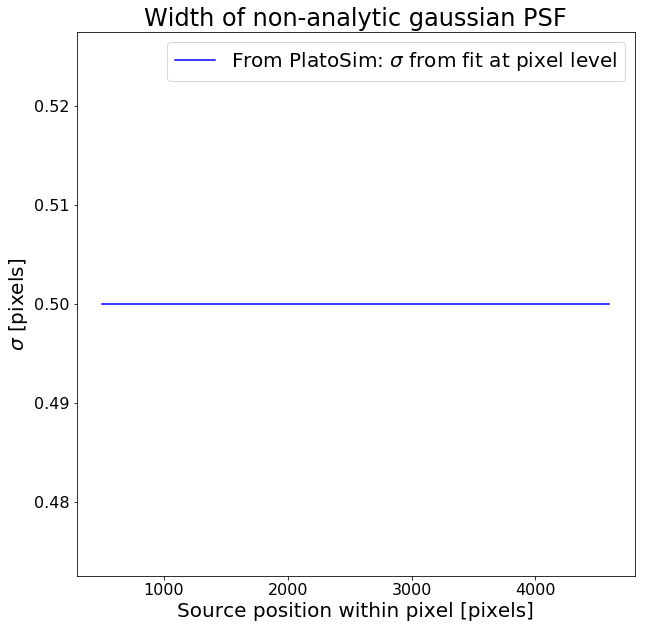

In [18]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)


# sigma = sim["PSF/AnalyticNonGaussian/Sigma/ConstantValue"]
plt.plot(offsets, fittedSigmaPixel, "b", label = "From PlatoSim: $\\sigma$ from fit at pixel level")

# plt.axhline(y = sigma, color = "g", label = "Input $\\sigma$")


########
# Layout
########

plt.title("Width of non-analytic gaussian PSF", fontsize = 24)
plt.xlabel("Source position within pixel [pixels]", fontsize = 20)
plt.ylabel("$\\sigma$ [pixels]", fontsize = 20)
# plt.ylim([0.2, 0.8])

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

In [19]:
filename = os.environ["PLATO_PROJECT_HOME"] + "/" + sim["PSF/MappedFromFile/Filename"]
psfFile = tables.open_file(filename)
children = psfFile.root.T6000

In [20]:
dim = 1024
sigma = 8.
# fittedSigmaSubPixelPsf = np.array([])

# for child in children:
#     print(child)
#     psf = np.array(child.az0)
#     params = fitGaussian2D(psf, np.max(psf), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
#     fittedSigmaSubPixelPsf = np.append(fittedSigmaSubPixelPsf, params[3]) 

for child in children:
    print(child)
    psf = np.array(child.az90)
    params = fitGaussian2D(psf, np.max(psf), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
    fittedSigmaSubPixelPsf = np.append(fittedSigmaSubPixelPsf, params[3])

for child in children:
    print(child)
    psf = np.array(child.az180)
    params = fitGaussian2D(psf, np.max(psf), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
    fittedSigmaSubPixelPsf = np.append(fittedSigmaSubPixelPsf, params[3]) 

for child in children:
    print(child)
    psf = np.array(child.az270)
    params = fitGaussian2D(psf, np.max(psf), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
    fittedSigmaSubPixelPsf = np.append(fittedSigmaSubPixelPsf, params[3])

fittedSigmaSubPixelPsf = fittedSigmaSubPixelPsf / numSubPixels  

/T6000/ar00000 (Group) ''


NameError: name 'fittedSigmaSubPixelPsf' is not defined

In [ ]:
distances = np.array([0, 1414, 2827, 4238, 5647, 7053, 8454, 9850, 11241, 12625, 14001, 15370, 16730, 18081, 18887])
distances = np.append(distances, distances)
distances = np.append(distances, distances)
distances = distances / 1000 # [degrees]

plateScaleArcsec = 15
distances = distances / plateScaleArcsec * constants.degree / constants.arcsec # [pixels]

In [ ]:
plt.plot(distances, fittedSigmaSubPixelPsf, "b+")

In [ ]:

fittedSigmaSubPixelPsf = fittedSigmaSubPixelPsf / numSubPixels  

In [ ]:
print(fittedSigmaSubPixelPsf)

In [ ]:
plt.imshow(psf)